# BO figure — NYX on the SZ3 base, Miranda on the SPERR base (one 1×4 panel)

Pure plotting: reads `bo_results/sz3_nyx.pkl` (from `nyx_miranda.ipynb`) and `bo_results/sperr_mir.pkl` (from `nyx_miranda_sperr.ipynb`). No GPU, no retraining — restyle freely.

loaded sz3_nyx.pkl + sperr_mir.pkl


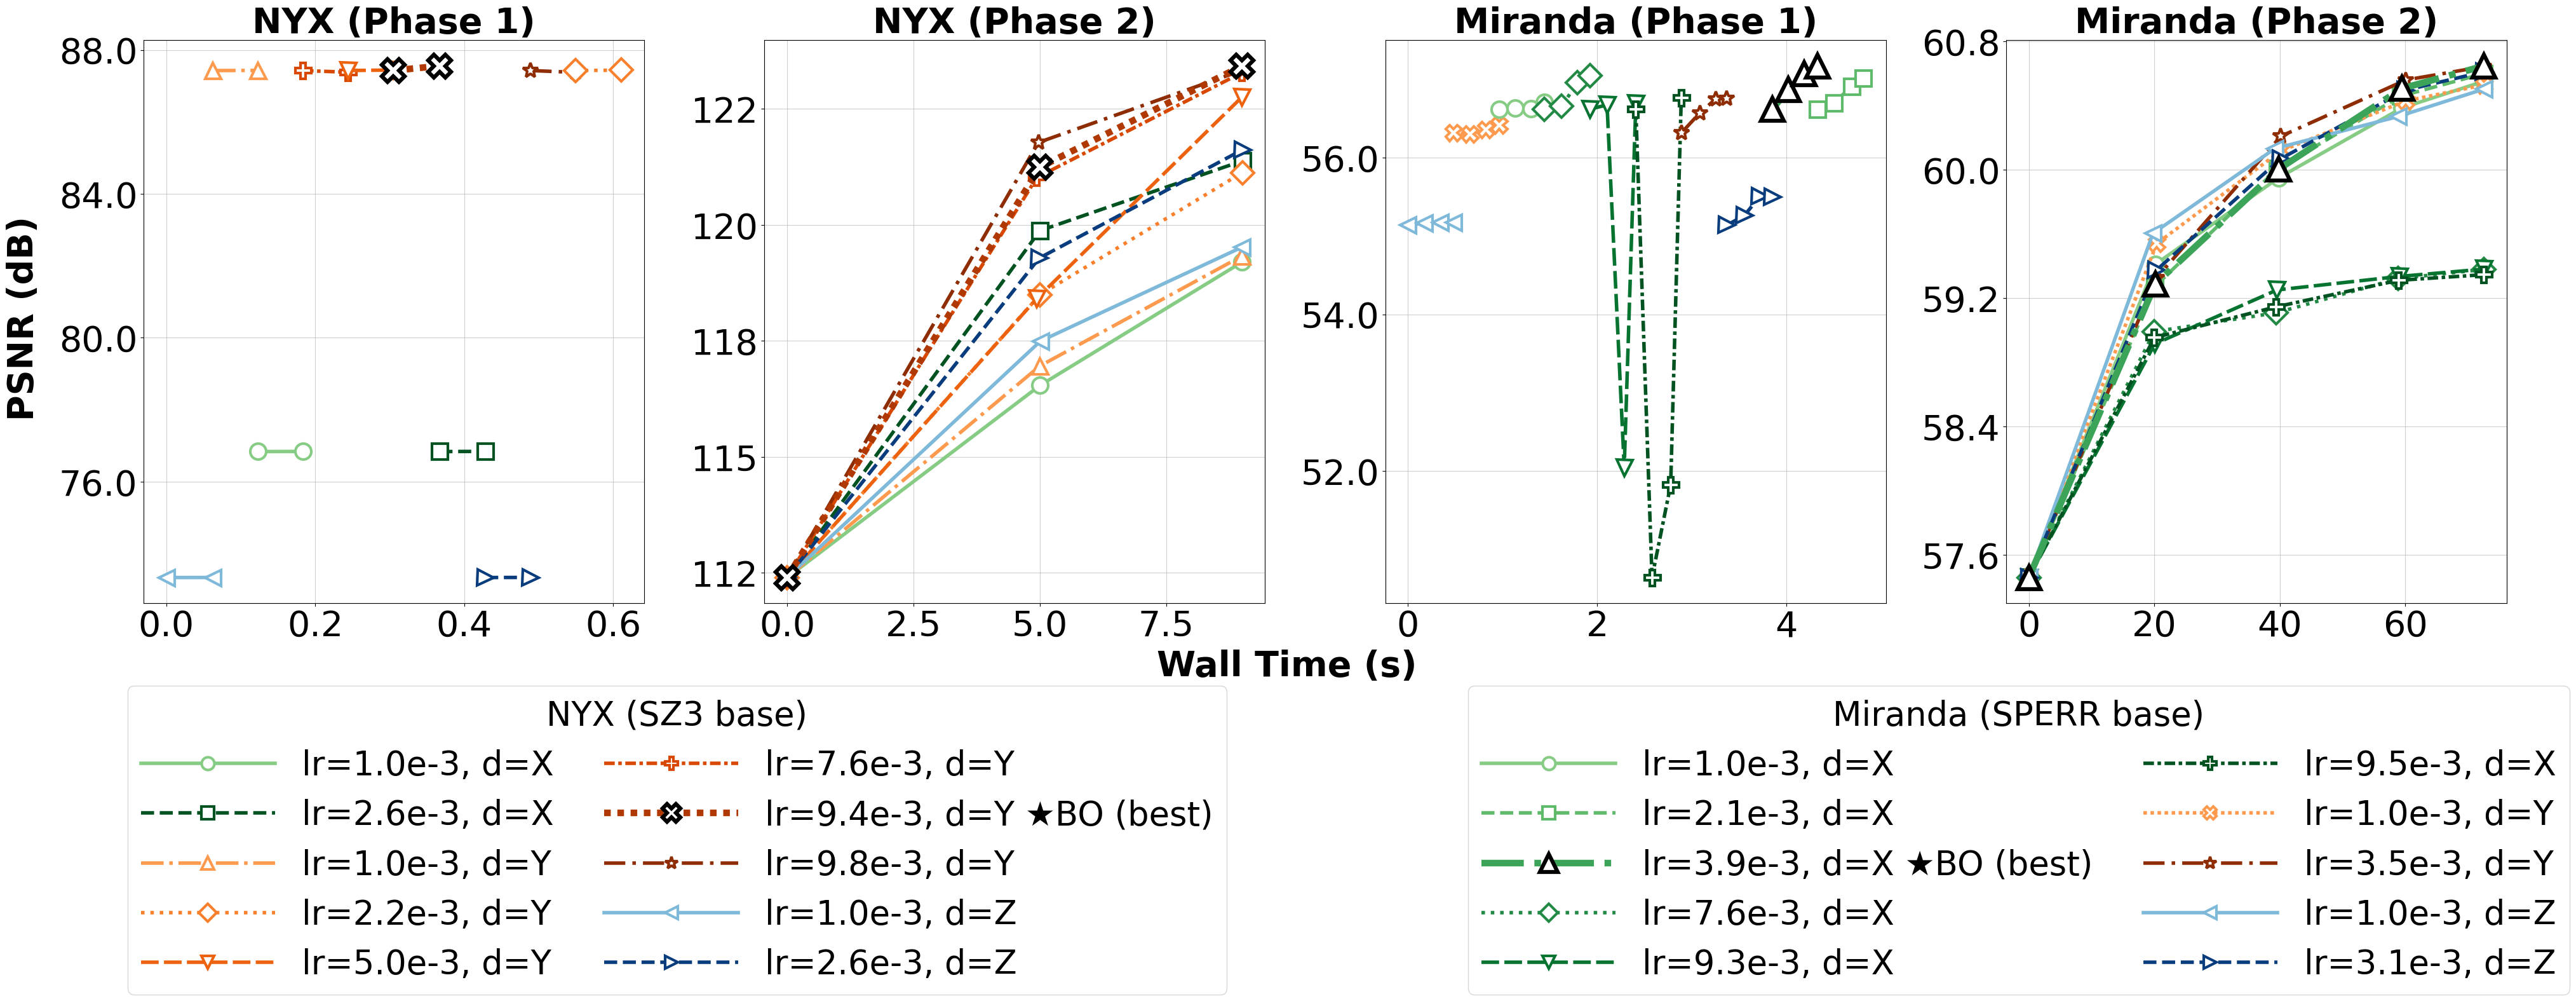

Saved: NYX_SZ3_Miranda_SPERR_1x4.pdf


In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as pe

# ── Combined 1x4 figure: Phase 1 | Phase 2 for NYX and Miranda ─────────────────
# Style: one colour family per slice direction (X green / Y orange / Z blue), lr
# encoded as shade within the family (light = small lr, dark = large lr); every curve
# additionally gets its own linestyle and hollow marker; ★BO is drawn thickest with a
# large black-edged hollow marker, best is outlined in black.
# Results are loaded from bo_results/<TAG>_{nyx,mir}.pkl when the run cells were not
# executed in this kernel, so the style can be iterated without retraining.
TAG      = "combo"                    # NYX from the SZ3 run, Miranda from the SPERR run
FIG_SIZE = (48, 8.0)
WSPACE   = 0.24
LEGEND_Y = -0.12
TITLE_FS = LABEL_FS = TICK_FS = 40
LEGEND_FS = LEGEND_TITLE_FS = 33
LW_NORM, LW_BEST, LW_PICK = 4.0, 5.0, 7.5
MS_NORM, MS_PICK = 18, 26
MEW_NORM, MEW_PICK = 3.0, 4.5   # marker edge width (hollow markers)
_LS = ["-", "--", "-.", ":", (0, (5, 1.5)), (0, (3, 1, 1, 1)), (0, (1, 1)), (0, (6, 2, 1, 2))]
_FAMILY  = {"X": plt.cm.Greens, "Y": plt.cm.Oranges, "Z": plt.cm.Blues}
_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "p", "8", "H"]

result_nyx = pickle.load(open(os.environ.get("BO_NYX_PKL", "bo_results/sz3_nyx.pkl"), "rb"))     # NYX  : SZ3 base
result_mir = pickle.load(open(os.environ.get("BO_MIR_PKL", "bo_results/sperr_mir.pkl"), "rb"))   # Miranda: SPERR base
print("loaded sz3_nyx.pkl + sperr_mir.pkl")

def _psnr_list(hist):
    return [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]

def _fmt_lr(lr):
    return f"{lr:.1e}".replace("e-0", "e-").replace("e+0", "e+")

def _style_map(R):
    """(lr, dir) -> dict(color, marker): shade by lr rank within its direction,
    marker unique per configuration (sorted by direction then lr)."""
    cfgs = sorted(set(R["full_histories"].keys()) | {(lr, d) for (_, lr, d, _) in R["study_trials"]},
                  key=lambda k: (k[1], k[0]))
    style = {}
    for d in ("X", "Y", "Z"):
        lrs = sorted({lr for (lr, dd) in cfgs if dd == d})
        for i, lr in enumerate(lrs):
            shade = 0.45 + 0.5 * (i / max(1, len(lrs) - 1))
            style[(lr, d)] = dict(color=_FAMILY[d](shade))
    for i, k in enumerate(cfgs):
        style[k]["marker"] = _MARKERS[i % len(_MARKERS)]
        style[k]["ls"]     = _LS[i % len(_LS)]
    return style

def _draw(ax, x, y, st, *, is_pick, is_best, label):
    lw = LW_PICK if is_pick else (LW_BEST if is_best else LW_NORM)
    kw = dict(color=st["color"], linewidth=lw, linestyle=st["ls"], marker=st["marker"],
              markersize=MS_PICK if is_pick else MS_NORM,
              markeredgewidth=MEW_PICK if (is_pick or is_best) else MEW_NORM,
              markerfacecolor="white",                       # hollow markers everywhere
              markeredgecolor=("black" if (is_pick or is_best) else st["color"]),
              zorder=10 if is_pick else (8 if is_best else 3), label=label)
    if is_best and not is_pick:
        kw["path_effects"] = [pe.Stroke(linewidth=lw + 3.5, foreground="black"), pe.Normal()]
    ax.plot(x, y, **kw)

def plot_phase1(ax, R, style):
    trials = sorted(R["study_trials"], key=lambda x: x[0])
    t_off = 0.0
    for (num, lr_t, d_t, val) in trials:
        hist = R["all_tune_histories"].get((lr_t, d_t), {})
        t_raw, p_raw = hist.get("time", []), _psnr_list(hist)
        if not t_raw or not p_raw:
            t_off += R["per_trial_cap"]; continue
        t_abs = [t_off + tt for tt in t_raw]
        is_pick = (lr_t == R["best_lr"] and d_t == R["best_direction"])
        _draw(ax, t_abs, p_raw, style[(lr_t, d_t)], is_pick=is_pick, is_best=False,
              label=f"lr={_fmt_lr(lr_t)}, d={d_t}" + (" ★BO" if is_pick else ""))
        t_off = t_abs[-1]
    ax.grid(True, alpha=0.6); ax.tick_params(axis="both", labelsize=TICK_FS)

def plot_phase2(ax, R, style):
    fw, pick = R["final_winner"], (R["best_lr"], R["best_direction"])
    for (lr, d), hist in sorted(R["full_histories"].items(), key=lambda kv: (kv[0][1], kv[0][0])):
        t_vals, p_vals = hist.get("time", []), _psnr_list(hist)
        if not t_vals or not p_vals:
            continue
        is_best, is_pick = (lr, d) == fw, (lr, d) == pick
        suffix = (" ★BO" if is_pick else "") + (" (best)" if is_best else "")
        _draw(ax, t_vals, p_vals, style[(lr, d)], is_pick=is_pick, is_best=is_best,
              label=f"lr={_fmt_lr(lr)}, d={d}{suffix}")
    ax.grid(True, alpha=0.6); ax.tick_params(axis="both", labelsize=TICK_FS)

def _fit_y_decimals(ax, nbins=4):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=nbins))
    lo, hi = ax.get_ylim(); span = max(hi - lo, 1e-12)
    dec = int(np.clip(np.ceil(-np.log10(span / nbins)) + 1, 1, 4))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter(f"%.{dec}f"))

st_nyx, st_mir = _style_map(result_nyx), _style_map(result_mir)
fig, axes = plt.subplots(1, 4, figsize=FIG_SIZE, gridspec_kw={"wspace": WSPACE})
plot_phase1(axes[0], result_nyx, st_nyx); plot_phase2(axes[1], result_nyx, st_nyx)
plot_phase1(axes[2], result_mir, st_mir); plot_phase2(axes[3], result_mir, st_mir)
for ax, t in zip(axes, ["NYX (Phase 1)", "NYX (Phase 2)", "Miranda (Phase 1)", "Miranda (Phase 2)"]):
    ax.set_title(t, fontsize=TITLE_FS, fontweight="bold")
    ax.yaxis.get_major_formatter().set_useOffset(False)
    ax.xaxis.get_major_formatter().set_useOffset(False)
_fit_y_decimals(axes[0]); _fit_y_decimals(axes[2])
axes[1].yaxis.set_major_locator(ticker.MaxNLocator(nbins=5)); axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))
axes[3].yaxis.set_major_locator(ticker.MaxNLocator(nbins=5)); axes[3].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
fig.supxlabel("Wall Time (s)", fontsize=LABEL_FS, fontweight="bold", y=-0.07)
fig.supylabel("PSNR (dB)", fontsize=LABEL_FS, fontweight="bold", x=0.08)

for ax_src, xpos, ttl in ((axes[1], 0.30, "NYX (SZ3 base)"), (axes[3], 0.74, "Miranda (SPERR base)")):
    h, l = ax_src.get_legend_handles_labels()
    fig.legend(h, l, loc="upper center", bbox_to_anchor=(xpos, LEGEND_Y), ncol=3,
               fontsize=LEGEND_FS, title=ttl, title_fontsize=LEGEND_TITLE_FS,
               handlelength=4.0, markerscale=0.8, columnspacing=1.5)

out_pdf = os.environ.get("BO_OUT_PDF", "NYX_SZ3_Miranda_SPERR_1x4.pdf")
plt.savefig(out_pdf, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")
